In [1]:
#Local Setup
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import copy
import random
import numpy as np
import pandas as pd

data_dir = r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\COMP9517_Team_500_40_10\content/Team_Dataset"

batch_size = 32
num_classes = 500
num_epochs = 20
LR = 1e-4
RUN_ID = 'convnext_tiny_Pre_Full_Aug'

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

Training on device: cuda:0


In [2]:

# Augmented Data
data_transforms_fully_aug = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),    # takes a random patch of the photo and stretches it to 224×224. Half the image is a safer floor for fine-grained work.
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3,
                               saturation=0.3, hue=0.03),       # Requires Fine Tuning
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),    # blanks out a random rectangle after the image is a tensor
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms_fully_aug[x]) for x in ['train', 'val']}  # For Full Aug
dataloaders = {x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=(x == 'train'), num_workers=8, persistent_workers=True, pin_memory=True) for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}


model = models.convnext_tiny(weights='DEFAULT')
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
class_names = image_datasets['train'].classes    # you'll need these later

In [3]:


train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_model_wts = copy.deepcopy(model.state_dict())                              # stored weights of the best model
best_acc = 0.0

print("Starting Experiment 3: ConvNeXt-Tiny From Pre-Trained Weights (Full Augmentation)")
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()       # Uses current batch statistics
        else:           
            model.eval()        # Uses running averages

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()       # Clears gradients

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)         # 32 Images as Input, 32 x 500 grid, where each image golds the score for all 500 species
                _, preds = torch.max(outputs, 1)    # Minds the maximum score from the 500 row, returns score value and position - position correlates directly to the actual species
                loss = criterion(outputs, labels)

                # Actual physical training
                if phase == 'train':
                    loss.backward()     # Calculates what direction the model should moves to reduce the loss
                    optimizer.step()    # Actualy moves the weights by amount (learning rate)

            running_loss += loss.item() * inputs.size(0)        #average loss for that batch
            running_corrects += torch.sum(preds == labels.data) #Sum of all predictions that were correct

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc)
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc)

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), rf'C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\ConvNeXt-Tiny\{RUN_ID}_best.pth')

    print()

    pd.DataFrame({
        'epoch': range(1, len(train_losses) + 1),
        'train_loss': train_losses, 'train_acc': train_accs,
        'val_loss': val_losses, 'val_acc': val_accs,
    }).to_csv(rf'C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\ConvNeXt-Tiny\{RUN_ID}_history.csv', index=False)

    scheduler.step()

model.load_state_dict(best_model_wts)

print(f'Experiment 3 Complete. Best Validation Accuracy: {best_acc:.4f}')

Starting Experiment 3: ConvNeXt-Tiny From Pre-Trained Weights (Full Augmentation)
Epoch 1/20
----------
Train Loss: 4.4850 Acc: 0.2898
Val Loss: 2.7926 Acc: 0.5758

Epoch 2/20
----------
Train Loss: 2.3711 Acc: 0.6804
Val Loss: 2.0392 Acc: 0.7204

Epoch 3/20
----------
Train Loss: 1.7862 Acc: 0.8118
Val Loss: 1.8482 Acc: 0.7642

Epoch 4/20
----------
Train Loss: 1.5256 Acc: 0.8748
Val Loss: 1.7471 Acc: 0.7908

Epoch 5/20
----------
Train Loss: 1.3655 Acc: 0.9207
Val Loss: 1.7150 Acc: 0.8010

Epoch 6/20
----------
Train Loss: 1.2726 Acc: 0.9455
Val Loss: 1.6893 Acc: 0.8112

Epoch 7/20
----------
Train Loss: 1.2068 Acc: 0.9619
Val Loss: 1.6712 Acc: 0.8158

Epoch 8/20
----------
Train Loss: 1.1725 Acc: 0.9699
Val Loss: 1.6553 Acc: 0.8192

Epoch 9/20
----------
Train Loss: 1.1384 Acc: 0.9772
Val Loss: 1.6521 Acc: 0.8148

Epoch 10/20
----------
Train Loss: 1.1200 Acc: 0.9810
Val Loss: 1.6524 Acc: 0.8218

Epoch 11/20
----------
Train Loss: 1.0962 Acc: 0.9838
Val Loss: 1.6441 Acc: 0.8244

Epo

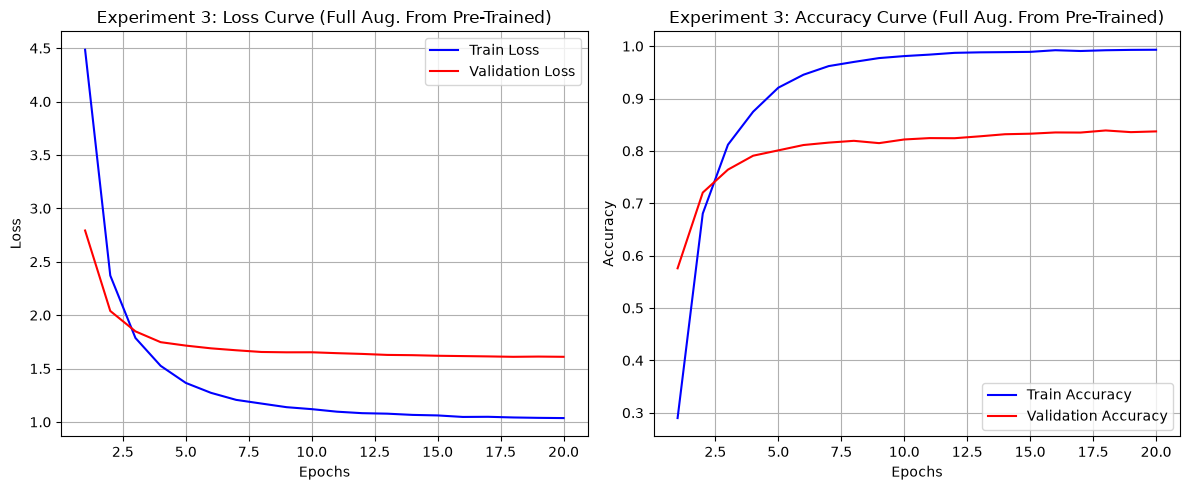

In [11]:
import matplotlib.pyplot as plt
CKPT = r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\ConvNeXt-Tiny"
EVAL_SPLIT = 'test' 

plt.figure(figsize=(12, 5))

# Subplot 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', color='red')
plt.title('Experiment 3: Loss Curve (Full Aug. From Pre-Trained)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accs, label='Train Accuracy', color='blue')
plt.plot(range(1, num_epochs+1), val_accs, label='Validation Accuracy', color='red')
plt.title('Experiment 3: Accuracy Curve (Full Aug. From Pre-Trained)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CKPT, f'{RUN_ID}_Loss_Accuracy_Curve.png'), dpi=150)
plt.show()

In [12]:
import time

CKPT = r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\ConvNeXt-Tiny"

EVAL_SPLIT = 'test'       

# model.load_state_dict(torch.load(os.path.join(CKPT, 'exp1_scratch_best.pth')))
# model = model.to(device)

eval_ds = datasets.ImageFolder(os.path.join(data_dir, EVAL_SPLIT), data_transforms_fully_aug['val'])
assert eval_ds.classes == image_datasets['train'].classes, "class lists differ!"
eval_dl = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=2)
class_names = eval_ds.classes

model.eval()
all_top5, all_conf = [], []

if device.type == 'cuda': torch.cuda.synchronize()
t0 = time.time()

with torch.no_grad():
    for inputs, _ in eval_dl:
        probs = model(inputs.to(device)).softmax(1)
        conf, top5 = probs.topk(5, dim=1)
        all_top5.append(top5.cpu())
        all_conf.append(conf[:, 0].cpu())

if device.type == 'cuda': torch.cuda.synchronize()
infer_secs = time.time() - t0

top5 = torch.cat(all_top5).numpy()

df = pd.DataFrame({
    'filepath':   [p for p, _ in eval_ds.samples],
    'true':       [y for _, y in eval_ds.samples],
    'pred':       top5[:, 0],
    'confidence': torch.cat(all_conf).numpy(),
})
for k in range(5):
    df[f'top{k+1}'] = top5[:, k]

df.to_csv(os.path.join(CKPT, f'{RUN_ID}_predictions.csv'), index=False)
print(f'{len(df)} images in {infer_secs:.1f}s  ({infer_secs*1000/len(df):.2f} ms/image)')

5000 images in 12.1s  (2.42 ms/image)


In [14]:
from sklearn.metrics import precision_recall_fscore_support, balanced_accuracy_score

df = pd.read_csv(os.path.join(CKPT, f'{RUN_ID}_predictions.csv'))

top1 = (df['pred'] == df['true']).mean()

top5_cols = [f'top{k}' for k in range(1, 6)]
top5_acc = (df[top5_cols].values == df['true'].values[:, None]).any(axis=1).mean()

p, r, f1, _ = precision_recall_fscore_support(
    df['true'], df['pred'], average='macro', zero_division=0)
bal = balanced_accuracy_score(df['true'], df['pred'])

print(f"Top-1 accuracy  : {top1:.4f}")
print(f"Top-5 accuracy  : {top5_acc:.4f}")
print(f"Balanced acc    : {bal:.4f}")
print(f"Macro precision : {p:.4f}")
print(f"Macro recall    : {r:.4f}")
print(f"Macro F1        : {f1:.4f}")

# one row per experiment, appended to a growing table
summary_path = os.path.join(r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\ResNet50\From Scratch\summary.csv")
pd.DataFrame([{
    'run': RUN_ID, 'arch': 'resnet18', 'augmentation': 'full',
    'epochs': num_epochs, 'top1': top1, 'top5': top5_acc, 'balanced_acc': bal,
    'macro_p': p, 'macro_r': r, 'macro_f1': f1,
    'best_val_acc': best_acc, 'ms_per_img': infer_secs * 1000 / len(df),
}]).to_csv(summary_path, mode='a', header=not os.path.exists(summary_path), index=False)

Top-1 accuracy  : 0.8376
Top-5 accuracy  : 0.9462
Balanced acc    : 0.8376
Macro precision : 0.8479
Macro recall    : 0.8376
Macro F1        : 0.8357


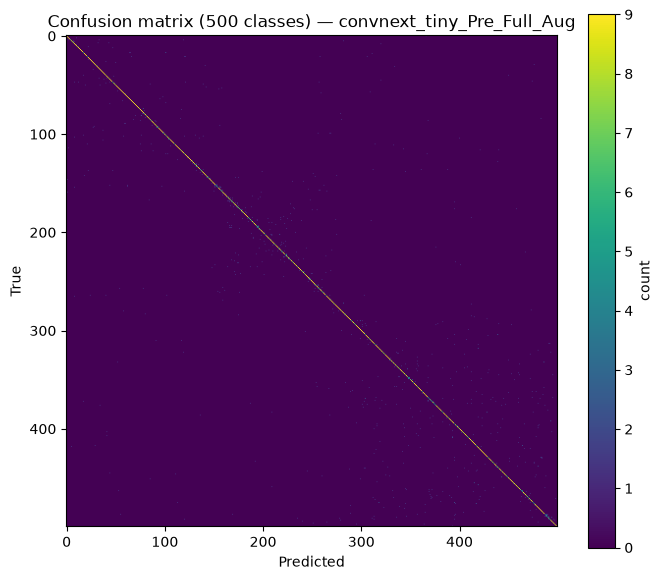


count  true species  →  predicted as
    5  09781_Plantae_Tracheophyta_Pinopsida_Pinales_Cupressaceae_Juniperus_deppeana  →  09785_Plantae_Tracheophyta_Pinopsida_Pinales_Cupressaceae_Juniperus_occidentalis
    5  04274_Animalia_Chordata_Aves_Passeriformes_Turdidae_Sialia_mexicana  →  04275_Animalia_Chordata_Aves_Passeriformes_Turdidae_Sialia_sialis
    4  07066_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_gigantea  →  07067_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_missurica
    4  07067_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_missurica  →  07066_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_gigantea
    4  03755_Animalia_Chordata_Aves_Passeriformes_Corvidae_Corvus_frugilegus  →  03759_Animalia_Chordata_Aves_Passeriformes_Corvidae_Corvus_ossifragus
    3  09449_Plantae_Tracheophyta_Magnoliopsida_Rosales_Rosaceae_Rosa_majalis  →  09452_Plantae_Tracheophyta_Magnoliopsida_Rosales_Rosaceae_Rosa_palustri

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df['true'], df['pred'], labels=range(num_classes))

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='viridis', vmax=np.percentile(cm, 99.9))
plt.colorbar(label='count')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion matrix ({num_classes} classes) — {RUN_ID}')
plt.tight_layout()
plt.savefig(os.path.join(CKPT, f'{RUN_ID}_confusion.png'), dpi=150)
plt.show()

off = cm.copy()
np.fill_diagonal(off, 0)
rows, cols = np.unravel_index(np.argsort(off, axis=None)[::-1][:15], off.shape)

print("\ncount  true species  →  predicted as")
for a, b in zip(rows, cols):
    print(f"{off[a,b]:5d}  {class_names[a]}  →  {class_names[b]}")

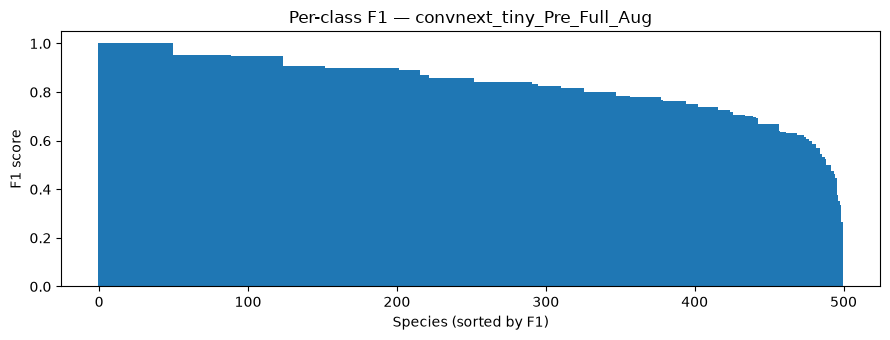

Species never correctly identified: 0 / 500

Most confident mistakes:
0.96  07067_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_missurica  called  07066_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_gigantea
      C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\COMP9517_Team_500_40_10\content/Team_Dataset\test\07067_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_missurica\011464de-e8ac-414c-ba23-dd1e7cdab649.jpg
0.92  04924_Animalia_Chordata_Reptilia_Squamata_Colubridae_Lampropeltis_splendida  called  04919_Animalia_Chordata_Reptilia_Squamata_Colubridae_Lampropeltis_calligaster
      C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\COMP9517_Team_500_40_10\content/Team_Dataset\test\04924_Animalia_Chordata_Reptilia_Squamata_Colubridae_Lampropeltis_splendida\13015faf-bb30-4331-93e2-f31aa8420460.jpg
0.92  07066_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_gigantea  called  07067_Plantae_Tracheophyta_Magnoliopsida_Asterales_

In [16]:
_, _, f1_per, _ = precision_recall_fscore_support(
    df['true'], df['pred'], average=None, labels=range(num_classes), zero_division=0)

plt.figure(figsize=(9, 3.5))
plt.bar(range(num_classes), np.sort(f1_per)[::-1], width=1.0)
plt.xlabel('Species (sorted by F1)'); plt.ylabel('F1 score')
plt.title(f'Per-class F1 — {RUN_ID}')
plt.tight_layout()
plt.savefig(os.path.join(CKPT, f'{RUN_ID}_perclass_f1.png'), dpi=150)
plt.show()

print(f"Species never correctly identified: {(f1_per == 0).sum()} / {num_classes}")

print("\nMost confident mistakes:")
for _, row in df[df.pred != df.true].nlargest(10, 'confidence').iterrows():
    print(f"{row.confidence:.2f}  {class_names[row.true]}  called  {class_names[row.pred]}")
    print(f"      {row.filepath}")